In [45]:
# conda create --name bcitoolbox python=3.10

from bcitoolbox_local import simulateVV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from helpers import get_best_models, print_parameters, print_r2

location = 'visible'
mup=True

In [46]:
strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}


fit_locations = ['visible', 'invisible']

groups = ['Low Vision', 'Sighted Control']
conditions = ['F0B0', 'F1B0', 'F1B1', 'F1B2']

def simulate_data(parameters, strategy_name, fitType, file_name,
                  modeling_data_path='csv/modeling/data/',
                  n_simulation=10000, biOnly=0):
    
    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    if len(behavior_data) < 10: return

    strategy = strategy_map.get(strategy_name[0])

    error, modelprop, dataprop, responsesSim, r2 = simulateVV(parameters, 
                                                              n_simulation, 
                                                              behavior_data, 
                                                              biOnly,
                                                              strategy, 
                                                              fitType,)

    return error, modelprop, dataprop, responsesSim, r2


In [47]:
# Simulate data for each subject
condition_map = None
best_models_df = get_best_models('bci', sigma_a=0.2, mup=mup)
# best_models_df = find_best_model_per_subject()
all_props = defaultdict(dict)

for loc in fit_locations: 
    location_df = best_models_df[best_models_df['location'] == loc]

    for index, row in location_df.iterrows():
        subject = row['subject_id']
        file_name = f"{subject}_{loc}.csv"
        Strategies = [row['strategy']]
        FitType = row['fit_type']
        model = 'bci'

        if condition_map is None:
            behavior_data = np.loadtxt(f'csv/modeling/data/{file_name}', delimiter=',')
            stimuli = behavior_data[:, [0, 1]]
            condition_map = np.unique(stimuli, axis=0)
            print("condition_map.shape:", condition_map.shape)

        print("\n=======================================")
        print(f"Simulating data for {subject} at {loc}")
        print("=======================================\n")

        # pcommon, sigmaU, sigmaD, sigmaZ, PZ_center, dU, dD = params.values()

        parameters = [
            row['pcommon'],
            row['sigma_v'],
            row['sigma_a'],
            row['sigma_p'],
            row['mu_p'],            
        ]
        results = simulate_data(parameters, Strategies, FitType, file_name)

        if results is not None:
            error, modelprop, dataprop, responsesSim, r2 = results
            # store simulated data
            all_props[subject][loc] = {
                'modelprop': modelprop,
                'dataprop': dataprop,
                'r2': r2
            }

            # Split modelprop and dataprop according to conditions
            for i, condition in enumerate(condition_map):
                all_props[subject][loc][f'F{int(condition[0])}B{int(condition[1])}'] = {
                    'model': model,
                    'Visual model': modelprop[0, i, :],
                    'Visual response': dataprop[0, i, :],
                }

group_data = {
    group: {
        cond: {
            'resp': {loc: [] for loc in fit_locations},
            'mod': {loc: [] for loc in fit_locations},
        }
        for cond in conditions
    }
    for group in groups
}

for sid in all_props.keys():
    group = 'Low Vision' if sid.startswith('LV') else 'Sighted Control'
    for cond in conditions:
        for fit_location in fit_locations:
            if fit_location in all_props[sid] and cond in all_props[sid][fit_location]:
                group_data[group][cond]['resp'][fit_location].append(all_props[sid][fit_location][cond]['Visual response'])
                group_data[group][cond]['mod'][fit_location].append(all_props[sid][fit_location][cond]['Visual model'])

stats = {group: {cond: {} for cond in conditions} for group in groups}

for group in groups:
    for cond in conditions:
        stats[group][cond]['resp_mean'] = {}
        stats[group][cond]['resp_sem'] = {}
        stats[group][cond]['mod_mean'] = {}
        stats[group][cond]['mod_sem'] = {}
        for fit_location in fit_locations:
            resp_stack = np.array(group_data[group][cond]['resp'][fit_location])
            mod_stack = np.array(group_data[group][cond]['mod'][fit_location])
            stats[group][cond]['resp_mean'][fit_location] = np.mean(resp_stack, axis=0)
            stats[group][cond]['resp_sem'][fit_location] = np.std(resp_stack, axis=0) / np.sqrt(len(resp_stack))
            stats[group][cond]['mod_mean'][fit_location] = np.mean(mod_stack, axis=0)
            stats[group][cond]['mod_sem'][fit_location] = np.std(mod_stack, axis=0) / np.sqrt(len(mod_stack))


condition_map.shape: (4, 2)

Simulating data for LV001 at visible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.5424651141780124 =====
===== DEBUG: sigma_v = 0.3940654107662624 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 0.6878140617421863 =====
===== DEBUG: mu_p = 0.5968411476591711 =====
R2 on all
0.8251052406239517
Sum Loglike    Optimal
-311.2780141292336 -121.63462655184387
Explainable variance, r2:
0.7060234114070476

Simulating data for LV002 at visible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.5210911722793697 =====
===== DEBUG: sigma_v = 2.098360611765796 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 2.291166124204396 =====
===== DEBUG: mu_p = 1.008901954269005 =====
R2 on all
0.5342748304237694
Sum Loglike    Optimal
-438.4903771960245 -148.96111394807593
Explainable variance, r2:
-0.06267526929459222

Simulating data fo

<Figure size 640x480 with 0 Axes>

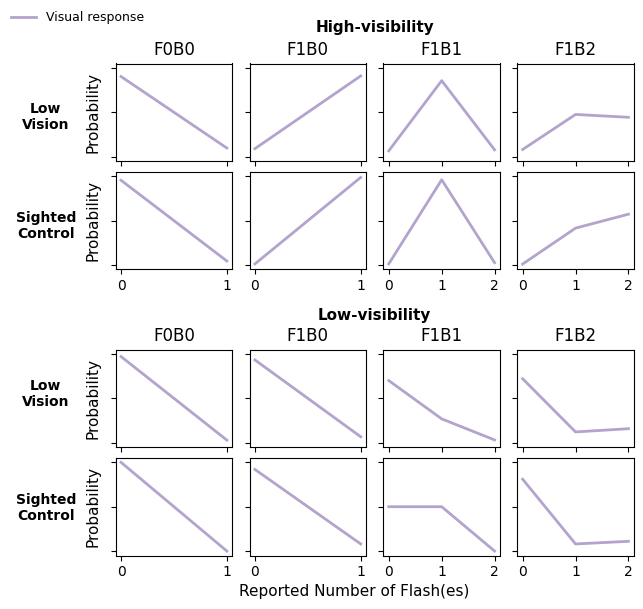

In [48]:
import matplotlib.pyplot as plt
import numpy as np

fit_col = '#6636a5'
resp_col = '#b3a3cd'

fig, axes = plt.subplots(
    5, len(conditions), figsize=(7, 6), sharey=True, # sharex=True, 
    gridspec_kw={'height_ratios': [1, 1, 0.6, 1, 1]}
)
gap_row = 2

for loc_idx, fit_location in enumerate(fit_locations):
    for group_idx, group in enumerate(groups):
        row = loc_idx * (len(groups) + 1) + group_idx
        for col, condition in enumerate(conditions):
            ax = axes[row, col]
            data = stats[group][condition]
            if 'B0' in condition:
                x = [0, 1]
                resp_data = data['resp_mean'][fit_location][:2]
                mod_data = data['mod_mean'][fit_location][:2]
                ax.set_xticks([0, 1])
            else:
                x = np.arange(len(data['resp_mean'][fit_location]))
                resp_data = data['resp_mean'][fit_location]
                mod_data = data['mod_mean'][fit_location]
                ax.set_xticks([0, 1, 2])

            ax.plot(x, resp_data, color=resp_col, label='Visual response', lw=2)
            # ax.plot(x, mod_data, color=fit_col, linestyle='--', label='Visual model fit', lw=1.5)
            ax.set_ylim(-0.05, 1.05)

            if col == 0:
                ax.set_ylabel('Probability', fontsize=11)
            else:
                ax.set_yticklabels([])
            if row == 0 or row == 3:
                ax.set_title(condition) #, fontweight='bold')
            # elif row == 1 or row == -1:

for ax in axes[gap_row, :]:
    ax.axis('off')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', fontsize=9, frameon=False)
fig.text(0.53, 0.96, 'High-visibility', va='center', ha='center', fontweight='bold', fontsize=11)
fig.text(0.53, 0.48, 'Low-visibility', va='center', ha='center',fontweight='bold', fontsize=11)
fig.text(0.06, 0.811, 'Low\nVision', va='center', ha='center', fontweight='bold', fontsize=10)
fig.text(0.06, 0.63, 'Sighted\nControl', va='center', ha='center', fontweight='bold', fontsize=10)
fig.text(0.06, 0.35, 'Low\nVision', va='center', ha='center', fontweight='bold', fontsize=10)
fig.text(0.06, 0.16, 'Sighted\nControl', va='center', ha='center', fontweight='bold', fontsize=10)
fig.text(0.5, 0.02, 'Reported Number of Flash(es)', va='center', ha='center', fontsize=11)

plt.subplots_adjust(left=0.16, bottom=0.08, top=0.9, hspace=0.12, wspace=0.15)
plt.savefig('../plots/fit_param.png', bbox_inches='tight')
plt.show()

In [38]:
print('High visibility location R2:')
r2_df = print_r2(model='bci', sigma_a=0.2, loc=location, mup=mup)
print('\nLow visibility location R2:')
r2_df = print_r2(model='bci', sigma_a=0.2, loc='invisible', mup=mup)

High visibility location R2:
            mean   sem
group                 
Control     1.00  0.00
Low Vision  0.97  0.02

Low visibility location R2:
            mean   sem
group                 
Control     0.73  0.12
Low Vision  0.91  0.04


In [39]:
param_df = print_parameters(model='bci', sigma_a=0.2, loc=location, mup=mup)

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

best_df = get_best_models(model='bci', sigma_a=0.2, mup=mup)
best_df = best_df[best_df['location']==location].copy()

parameters = ["pcommon", "sigma_v", "sigma_p", "mu_p"] if mup else ["pcommon", "sigma_v", "sigma_p"]

pivot_df = best_df.pivot(index='subject_id', columns='group', values=parameters)
    
results = []

for param in parameters:
    group_control = best_df[best_df['group'] == 'Control'][param].dropna()
    group_lv = best_df[best_df['group'] == 'Low Vision'][param].dropna()
    
    stat, p_val = mannwhitneyu(group_control, group_lv, alternative='two-sided')
    
    results.append({
        'Parameter': param,
        'U_stat': stat,
        'p_raw': p_val,
        'N_Control': len(group_control),
        'N_LowVision': len(group_lv)
    })

stats_df = pd.DataFrame(results)
_, p_corr, _, _ = multipletests(stats_df['p_raw'], method='bonferroni')
stats_df['p_corrected'] = p_corr
stats_df['Significant'] = stats_df['p_corrected'] < 0.05

print("\n======== Mann-Whitney U Test Results ========")
# print(stats_df)
print(stats_df[['Parameter', 'N_Control', 'N_LowVision', 'U_stat', 'p_corrected', 'Significant']].to_string(index=False))


======== BCI Parameters (Mean ± SEM) =============
                pcommon      sigma_v      sigma_p         mu_p
group                                                         
Control     0.71 ± 0.07  1.40 ± 0.21  0.74 ± 0.04  1.38 ± 0.10
Low Vision  0.42 ± 0.08  1.64 ± 0.22  1.10 ± 0.16  1.24 ± 0.19

======== Mann-Whitney U Test Results ========
Parameter  N_Control  N_LowVision  U_stat  p_corrected  Significant
  pcommon         21           19   300.0     0.027044         True
  sigma_v         21           19   165.0     1.000000        False
  sigma_p         21           19   145.0     0.574380        False
     mu_p         21           19   272.0     0.204683        False


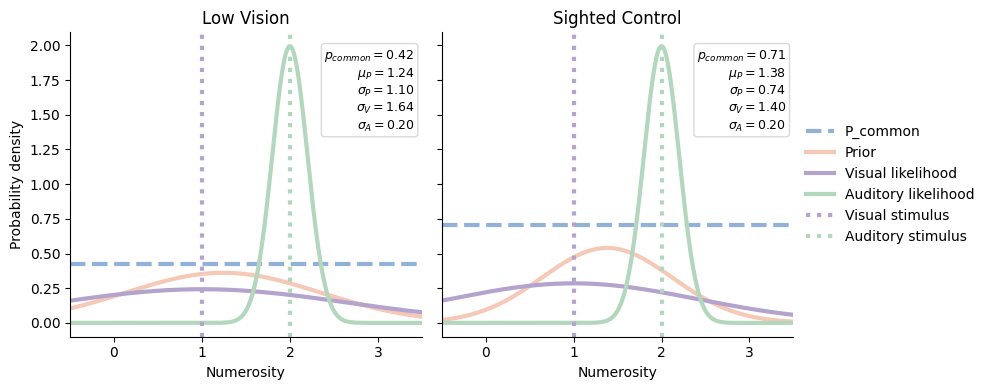

In [40]:
from scipy.stats import norm

visible_bci_df = get_best_models(model='bci', sigma_a=0.2, mup=mup)
visible_bci_df = visible_bci_df[visible_bci_df['location'] == location].copy()
visible_bci_df['group'] = visible_bci_df['group'].replace({'Control': 'Sighted Control'})

# Plot the F1B2 encoding distributions by default.
visual_center = 1
auditory_center = 2
x = np.linspace(-1, 4, 1000)

parameter_cols = ['pcommon', 'mu_p', 'sigma_p', 'sigma_v', 'sigma_a']
param_summary = (
    visible_bci_df
    .groupby('group', observed=True)[parameter_cols]
    .mean()
    .reindex(groups)
)

vis_col = '#b3a3cd'
aud_col = '#b3d7bd'
prior_col ='#f6c8b6'
lw = 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
# fig.suptitle('Response Distribution for Fitted BCI Parameters (Visible Locations)', fontweight='bold')

for ax, group in zip(axes, groups):
    params = param_summary.loc[group]
    n_subjects = visible_bci_df.loc[visible_bci_df['group'] == group, 'subject_id'].nunique()

    prior_pdf = norm.pdf(x, params['mu_p'], params['sigma_p'])
    visual_pdf = norm.pdf(x, visual_center, params['sigma_v'])
    auditory_pdf = norm.pdf(x, auditory_center, params['sigma_a'])

    ax.axhline(params["pcommon"], color="#92b1d9", lw=lw, linestyle='--', label='P_common')
    ax.plot(x, prior_pdf, color=prior_col, lw=lw, label='Prior')
    ax.plot(x, visual_pdf, color=vis_col, lw=lw, label='Visual likelihood')
    ax.plot(x, auditory_pdf, color=aud_col, lw=lw, label='Auditory likelihood')

    ax.axvline(visual_center, color=vis_col, linestyle=':', lw=lw, label='Visual stimulus')
    ax.axvline(auditory_center, color=aud_col, linestyle=':', lw=lw, label='Auditory stimulus')

    ax.text(
        0.98, 0.95,
        '\n'.join([
            rf'$p_{{common}}={params["pcommon"]:.2f}$',
            rf'$\mu_P={params["mu_p"]:.2f}$',
            rf'$\sigma_P={params["sigma_p"]:.2f}$',
            rf'$\sigma_V={params["sigma_v"]:.2f}$',
            rf'$\sigma_A={params["sigma_a"]:.2f}$',
        ]),
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='0.85', boxstyle='round,pad=0.25')
    )

    ax.set_title(group)
    ax.set_xlabel('Numerosity')
    ax.set_xticks(np.arange(0, 4, 1))
    ax.set_xlim(-0.5, 3.5)

axes[0].set_ylabel('Probability density')
axes[1].legend(frameon=False, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
sns.despine(fig=fig)
plt.tight_layout()
plt.savefig('../plots/bci_param_dist_visible.png', dpi=300, bbox_inches='tight')
plt.show()


In [41]:
import pingouin as pg
import pandas as pd

if mup:
    df = pd.read_csv('csv/modeling/outputs/free_mup/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p', 'mu_p']

else:
    df = pd.read_csv('csv/modeling/outputs/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p']

groups = ['Low Vision', 'Control']

results = []

for location in [location]:
    location_df = df[df['location'] == location].copy()

    for parameter in parameters:
        low_vision_values = location_df.loc[location_df['group'] == groups[0], parameter].dropna().to_numpy()
        control_values = location_df.loc[location_df['group'] == groups[1], parameter].dropna().to_numpy()

        if len(low_vision_values) < 2 or len(control_values) < 2:
            continue

        ttest_res = pg.ttest(low_vision_values, control_values, paired=False)
        t_value = float(ttest_res['T'].iloc[0])
        p_value = float(ttest_res['p_val'].iloc[0])
        bf10 = float(pg.bayesfactor_ttest(t_value, len(low_vision_values), len(control_values), paired=False))

        results.append({
            'location': location,
            'parameter': parameter,
            'bf10': bf10,
            'low_vision_mean': low_vision_values.mean(),
            'low_vision_sem': low_vision_values.std(ddof=1) / np.sqrt(len(low_vision_values)),
            'control_mean': control_values.mean(),
            'control_sem': control_values.std(ddof=1) / np.sqrt(len(control_values)),
            'mean_difference': low_vision_values.mean() - control_values.mean(),
            't_value': t_value,
            'p_value': p_value,
            'n_low_vision': len(low_vision_values),
            'n_control': len(control_values),
        })

results_df = pd.DataFrame(results)
results_df['p_bonferroni'] = (results_df['p_value'] * len(results_df)).clip(upper=1.0)
results_df[['low_vision_mean', 'low_vision_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']] = (
    results_df[['low_vision_mean', 'low_vision_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']].round(2)
)

results_df.sort_values(['location', 'parameter']).reset_index(drop=True)

,location,parameter,bf10,low_vision_mean,low_vision_sem,control_mean,control_sem,mean_difference,t_value,p_value,n_low_vision,n_control,p_bonferroni
0,visible,mu_p,0.37,1.24,0.19,1.38,0.10,-0.14,-0.66,0.52,19,21,1.00
1,visible,pcommon,4.80,0.42,0.08,0.71,0.07,-0.29,-2.69,0.01,19,21,0.04
2,visible,sigma_p,1.99,1.10,0.16,0.74,0.04,0.37,2.20,0.04,19,21,0.16
3,visible,sigma_v,0.40,1.64,0.22,1.40,0.21,0.24,0.81,0.42,19,21,1.00


In [42]:
import pingouin as pg
import pandas as pd

if mup:
    df = pd.read_csv('csv/modeling/outputs/free_mup/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p', 'mu_p']

else:
    df = pd.read_csv('csv/modeling/outputs/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p']

groups = ['Low Vision', 'Control']

results = []

for location in ['invisible']:
    location_df = df[df['location'] == location].copy()

    for parameter in parameters:
        low_vision_values = location_df.loc[location_df['group'] == groups[0], parameter].dropna().to_numpy()
        control_values = location_df.loc[location_df['group'] == groups[1], parameter].dropna().to_numpy()

        if len(low_vision_values) < 2 or len(control_values) < 2:
            continue

        ttest_res = pg.ttest(low_vision_values, control_values, paired=False)
        t_value = float(ttest_res['T'].iloc[0])
        try:
            p_value = float(ttest_res['p-val'].iloc[0])
        except:
            p_value = float(ttest_res['p_val'].iloc[0])
        bf10 = float(pg.bayesfactor_ttest(t_value, len(low_vision_values), len(control_values), paired=False))

        results.append({
            'location': location,
            'parameter': parameter,
            'bf10': bf10,
            'low_vision_mean': low_vision_values.mean(),
            'low_vision_sem': low_vision_values.std(ddof=1) / np.sqrt(len(low_vision_values)),
            'control_mean': control_values.mean(),
            'control_sem': control_values.std(ddof=1) / np.sqrt(len(control_values)),
            'mean_difference': low_vision_values.mean() - control_values.mean(),
            't_value': t_value,
            'p_value': p_value,
            'n_low_vision': len(low_vision_values),
            'n_control': len(control_values),
        })

results_df = pd.DataFrame(results)
results_df['p_bonferroni'] = (results_df['p_value'] * len(results_df)).clip(upper=1.0)
results_df[['low_vision_mean', 'low_vision_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']] = (
    results_df[['low_vision_mean', 'low_vision_sem', 'control_mean', 'control_sem', 'mean_difference', 't_value', 'p_value', 'p_bonferroni', 'bf10']].round(2)
)

results_df.sort_values(['location', 'parameter']).reset_index(drop=True)

,location,parameter,bf10,low_vision_mean,low_vision_sem,control_mean,control_sem,mean_difference,t_value,p_value,n_low_vision,n_control,p_bonferroni
0,invisible,mu_p,0.65,0.30,0.13,0.82,0.44,-0.51,-1.11,0.32,17,5,1.00
1,invisible,pcommon,0.50,0.20,0.07,0.30,0.13,-0.09,-0.66,0.53,17,5,1.00
2,invisible,sigma_p,0.56,0.91,0.24,1.49,0.62,-0.58,-0.87,0.42,17,5,1.00
3,invisible,sigma_v,1.11,1.08,0.17,0.77,0.07,0.31,1.72,0.10,17,5,0.41


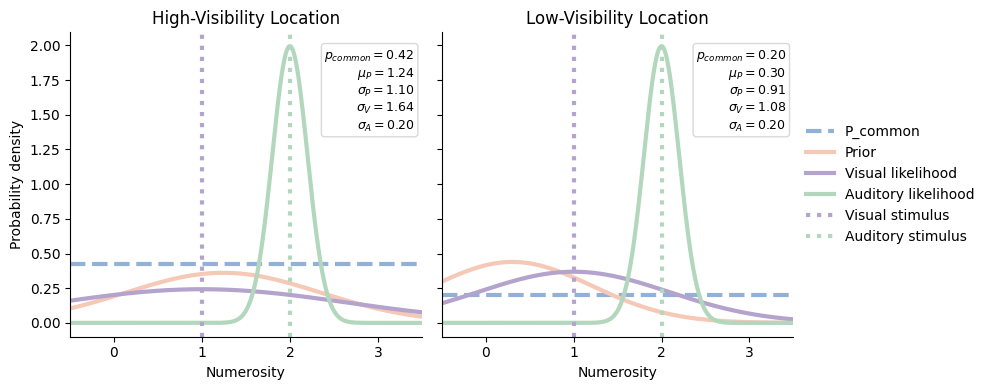

In [43]:
from scipy.stats import norm

visible_bci_df = get_best_models(model='bci', sigma_a=0.2, mup=mup)
visible_bci_df = visible_bci_df[visible_bci_df['location'] == 'visible'].copy()
# visible_bci_df['group'] = visible_bci_df['group'].replace({'Control': 'Sighted Control'})

invisible_bci_df = get_best_models(model='bci', sigma_a=0.2, mup=mup)
invisible_bci_df = invisible_bci_df[invisible_bci_df['location'] == 'invisible'].copy()
# invisible_bci_df['group'] = invisible_bci_df['group'].replace({'Control': 'Sighted Control'})

dfs = [visible_bci_df, invisible_bci_df]

# Plot the F1B2 encoding distributions by default.
visual_center = 1
auditory_center = 2
x = np.linspace(-1, 4, 1000)

vis_col = '#b3a3cd'
aud_col = '#b3d7bd'
prior_col ='#f6c8b6'
lw = 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
# fig.suptitle('Response Distribution for Fitted BCI Parameters (Visible Locations)', fontweight='bold')

parameter_cols = ['pcommon', 'mu_p', 'sigma_p', 'sigma_v', 'sigma_a']

for ax, df in zip(axes, dfs):
    param_summary = (
        df
        .groupby('group', observed=True)[parameter_cols]
        .mean()
        .reindex(groups)
    )
    params = param_summary.loc['Low Vision']
    n_subjects = df.loc[df['group'] == 'Low Vision', 'subject_id'].nunique()

    prior_pdf = norm.pdf(x, params['mu_p'], params['sigma_p'])
    visual_pdf = norm.pdf(x, visual_center, params['sigma_v'])
    auditory_pdf = norm.pdf(x, auditory_center, params['sigma_a'])

    ax.axhline(params["pcommon"], color="#92b1d9", lw=lw, linestyle='--', label='P_common')
    ax.plot(x, prior_pdf, color=prior_col, lw=lw, label='Prior')
    ax.plot(x, visual_pdf, color=vis_col, lw=lw, label='Visual likelihood')
    ax.plot(x, auditory_pdf, color=aud_col, lw=lw, label='Auditory likelihood')

    ax.axvline(visual_center, color=vis_col, linestyle=':', lw=lw, label='Visual stimulus')
    ax.axvline(auditory_center, color=aud_col, linestyle=':', lw=lw, label='Auditory stimulus')

    ax.text(
        0.98, 0.95,
        '\n'.join([
            rf'$p_{{common}}={params["pcommon"]:.2f}$',
            rf'$\mu_P={params["mu_p"]:.2f}$',
            rf'$\sigma_P={params["sigma_p"]:.2f}$',
            rf'$\sigma_V={params["sigma_v"]:.2f}$',
            rf'$\sigma_A={params["sigma_a"]:.2f}$',
        ]),
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='0.85', boxstyle='round,pad=0.25')
    )

    # ax.set_title(group)
    ax.set_xlabel('Numerosity')
    ax.set_xticks(np.arange(0, 4, 1))
    ax.set_xlim(-0.5, 3.5)
axes[0].set_title('High-Visibility Location')
axes[1].set_title('Low-Visibility Location')
axes[0].set_ylabel('Probability density')
axes[1].legend(frameon=False, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
sns.despine(fig=fig)
plt.tight_layout()
plt.savefig('../plots/bci_param_dist_patient.png', dpi=300, bbox_inches='tight')
plt.show()


In [44]:
import pingouin as pg
import pandas as pd
import numpy as np

if mup:
    df = pd.read_csv('csv/modeling/outputs/free_mup/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p', 'mu_p']
else:
    df = pd.read_csv('csv/modeling/outputs/sigma_a_p2/bci_best_models.csv')
    parameters = ['pcommon', 'sigma_v', 'sigma_p']

group = 'Low Vision'
locations = ['visible', 'invisible']

results = []

group_df = df[df['group'] == group].copy()

for parameter in parameters:
    visible_values = group_df.loc[group_df['location'] == locations[0], parameter].dropna().to_numpy()
    invisible_values = group_df.loc[group_df['location'] == locations[1], parameter].dropna().to_numpy()

    if len(visible_values) < 2 or len(invisible_values) < 2:
        continue

    # Use paired=True only if visible/invisible rows are matched by subject.
    # If not matched, change paired=True to paired=False.
    ttest_res = pg.ttest(visible_values, invisible_values, paired=True)

    t_value = float(ttest_res['T'].iloc[0])
    p_value = float(ttest_res['p_val'].iloc[0])
    bf10 = float(pg.bayesfactor_ttest(t_value, len(visible_values))) #, paired=True))

    results.append({
        'group': group,
        'parameter': parameter,
        'bf10': bf10,
        'visible_mean': visible_values.mean(),
        'visible_sem': visible_values.std(ddof=1) / np.sqrt(len(visible_values)),
        'invisible_mean': invisible_values.mean(),
        'invisible_sem': invisible_values.std(ddof=1) / np.sqrt(len(invisible_values)),
        'mean_difference_visible_minus_invisible': visible_values.mean() - invisible_values.mean(),
        't_value': t_value,
        'p_value': p_value,
        'n_visible': len(visible_values),
        'n_invisible': len(invisible_values),
    })

results_df = pd.DataFrame(results)

results_df['p_bonferroni'] = (
    results_df['p_value'] * len(results_df)
).clip(upper=1.0)

cols_to_round = [
    'visible_mean', 'visible_sem',
    'invisible_mean', 'invisible_sem',
    'mean_difference_visible_minus_invisible',
    't_value', 'p_value', 'p_bonferroni', 'bf10'
]

results_df[cols_to_round] = results_df[cols_to_round].round(2)

results_df.sort_values(['parameter']).reset_index(drop=True)

c:\Users\Ailene\miniconda3\envs\illusory-mapping\Lib\site-packages\pingouin\parametric.py:225: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")
c:\Users\Ailene\miniconda3\envs\illusory-mapping\Lib\site-packages\pingouin\parametric.py:225: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")
c:\Users\Ailene\miniconda3\envs\illusory-mapping\Lib\site-packages\pingouin\parametric.py:225: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")
c:\Users\Ailene\miniconda3\envs\illusory-mapping\Lib\site-packages\pingouin\parametric.py:225: UserWarning: x and y have unequal sizes. Switching to paired == False. Che

,group,parameter,bf10,visible_mean,visible_sem,invisible_mean,invisible_sem,mean_difference_visible_minus_invisible,t_value,p_value,n_visible,n_invisible,p_bonferroni
0,Low Vision,mu_p,61.68,1.24,0.19,0.30,0.13,0.94,4.19,0.00,19,17,0.00
1,Low Vision,pcommon,1.37,0.42,0.08,0.20,0.07,0.22,2.08,0.05,19,17,0.18
2,Low Vision,sigma_p,0.29,1.10,0.16,0.91,0.24,0.20,0.68,0.50,19,17,1.00
3,Low Vision,sigma_v,1.26,1.64,0.22,1.08,0.17,0.56,2.02,0.05,19,17,0.21
